# Plant Disease Recognition

## Importing Libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
 print(tf.config.list_physical_devices('CPU'))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [5]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [6]:
cnn = tf.keras.models.Sequential()

In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [10]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [11]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [12]:
cnn.add(tf.keras.layers.Dropout(0.25))

In [13]:
cnn.add(tf.keras.layers.Flatten())

In [14]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [15]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [16]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

In [17]:
cnn.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [19]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 [==============================] - 7417s 3s/step - loss: 1.3498 - accuracy: 0.6022 - val_loss: 0.5121 - val_accuracy: 0.8359
Epoch 2/10
2197/2197 [==============================] - 7595s 3s/step - loss: 0.4475 - accuracy: 0.8582 - val_loss: 0.2618 - val_accuracy: 0.9155
Epoch 3/10
2197/2197 [==============================] - 7410s 3s/step - loss: 0.2661 - accuracy: 0.9138 - val_loss: 0.2149 - val_accuracy: 0.9317
Epoch 4/10
2197/2197 [==============================] - 7660s 3s/step - loss: 0.1791 - accuracy: 0.9417 - val_loss: 0.1705 - val_accuracy: 0.9438
Epoch 5/10
2197/2197 [==============================] - 7612s 3s/step - loss: 0.1353 - accuracy: 0.9553 - val_loss: 0.2343 - val_accuracy: 0.9262
Epoch 6/10
2197/2197 [==============================] - 7517s 3s/step - loss: 0.1067 - accuracy: 0.9643 - val_loss: 0.1239 - val_accuracy: 0.9620
Epoch 7/10
2197/2197 [==============================] - 36313s 17s/step - loss: 0.0831 - accuracy: 0.9720 - val_loss: 0.1218

## Model Evaluation

In [20]:
#Model Evaluation on Training Set
train_loss, train_acc = cnn.evaluate(training_set)

2197/2197 [==============================] - 1671s 760ms/step - loss: 0.0330 - accuracy: 0.9896


In [21]:
print(train_loss, train_acc)

0.03297417238354683 0.9896294474601746


In [22]:
#Model Evaluation on Validation Set
val_loss, val_acc = cnn.evaluate(validation_set)

550/550 [==============================] - 430s 780ms/step - loss: 0.1200 - accuracy: 0.9642


In [23]:
print(val_loss, val_acc)

0.11999806016683578 0.9642044305801392


In [39]:
cnn.save("trained_model.h5")

In [24]:
#Saving the model
cnn.save("trained_model.keras")

In [41]:
cnn.save("training_model", save_format="tf")

INFO:tensorflow:Assets written to: training_model\assets


INFO:tensorflow:Assets written to: training_model\assets


In [25]:
training_history.history

{'loss': [1.3498035669326782,
  0.4475157558917999,
  0.26611068844795227,
  0.17911981046199799,
  0.13533058762550354,
  0.10669676959514618,
  0.083066426217556,
  0.07487432658672333,
  0.06275030970573425,
  0.058113470673561096],
 'accuracy': [0.6022192239761353,
  0.8582402467727661,
  0.9137634038925171,
  0.9416601657867432,
  0.9553169012069702,
  0.9643075466156006,
  0.9719752669334412,
  0.9756739735603333,
  0.979898989200592,
  0.9815776348114014],
 'val_loss': [0.5121163725852966,
  0.2617816627025604,
  0.21486933529376984,
  0.1705242544412613,
  0.23429833352565765,
  0.12393446266651154,
  0.12180417776107788,
  0.12861138582229614,
  0.09707389026880264,
  0.11999807506799698],
 'val_accuracy': [0.8359321355819702,
  0.9155474901199341,
  0.9316526055335999,
  0.9438310861587524,
  0.9262462854385376,
  0.9619849920272827,
  0.9629524350166321,
  0.9585704803466797,
  0.9704643487930298,
  0.9642044305801392]}

In [26]:
#Recording history in json
import json
with open("training_hist.json", "w") as f:
    json.dump(training_history.history, f)

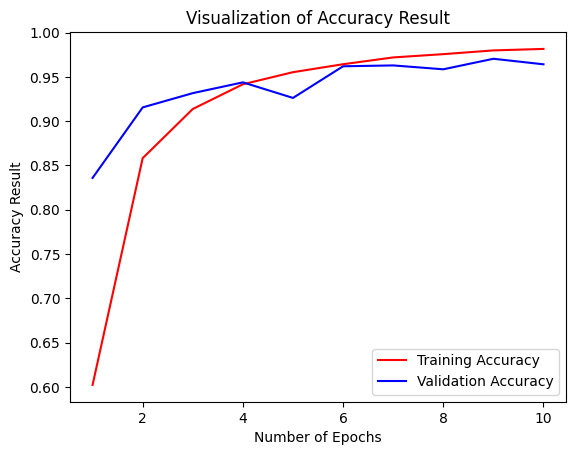

In [27]:
#Accuracy Visualization
epochs = [i for i in range(1, 11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [28]:
#Model Evaluation using some other metrics
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [29]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [30]:
y_pred = cnn.predict(test_set)
y_pred, y_pred.shape

550/550 [==============================] - 408s 741ms/step


(array([[1.0000000e+00, 3.2595956e-10, 5.2848195e-12, ..., 1.9042645e-16,
         8.2739883e-16, 4.0735009e-15],
        [1.0000000e+00, 3.6724833e-13, 6.6017439e-13, ..., 4.2301593e-19,
         1.5982438e-17, 7.4399271e-18],
        [1.0000000e+00, 1.7486386e-12, 1.6195961e-13, ..., 1.5211191e-20,
         1.7897901e-18, 6.2283499e-18],
        ...,
        [2.9911826e-11, 2.0702871e-16, 2.8145264e-11, ..., 7.7317981e-15,
         1.1826926e-14, 1.0000000e+00],
        [8.0615359e-10, 5.1842921e-13, 6.4407439e-09, ..., 3.0367479e-11,
         1.5451283e-11, 9.9999869e-01],
        [2.7767985e-10, 1.9916330e-13, 6.3263249e-11, ..., 6.5326766e-14,
         3.5095692e-12, 9.9999857e-01]], dtype=float32),
 (17572, 38))

In [31]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [32]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories#gives output in terms of one-hot encoding

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [33]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.98      0.95       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.96      0.99      0.97       440
                                   Apple___healthy       0.96      0.97      0.97       502
                               Blueberry___healthy       0.99      0.95      0.97       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.94      0.88      0.91       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.98      0.

## Confusion Matrix

In [37]:
cm = confusion_matrix(Y_true,predicted_categories)

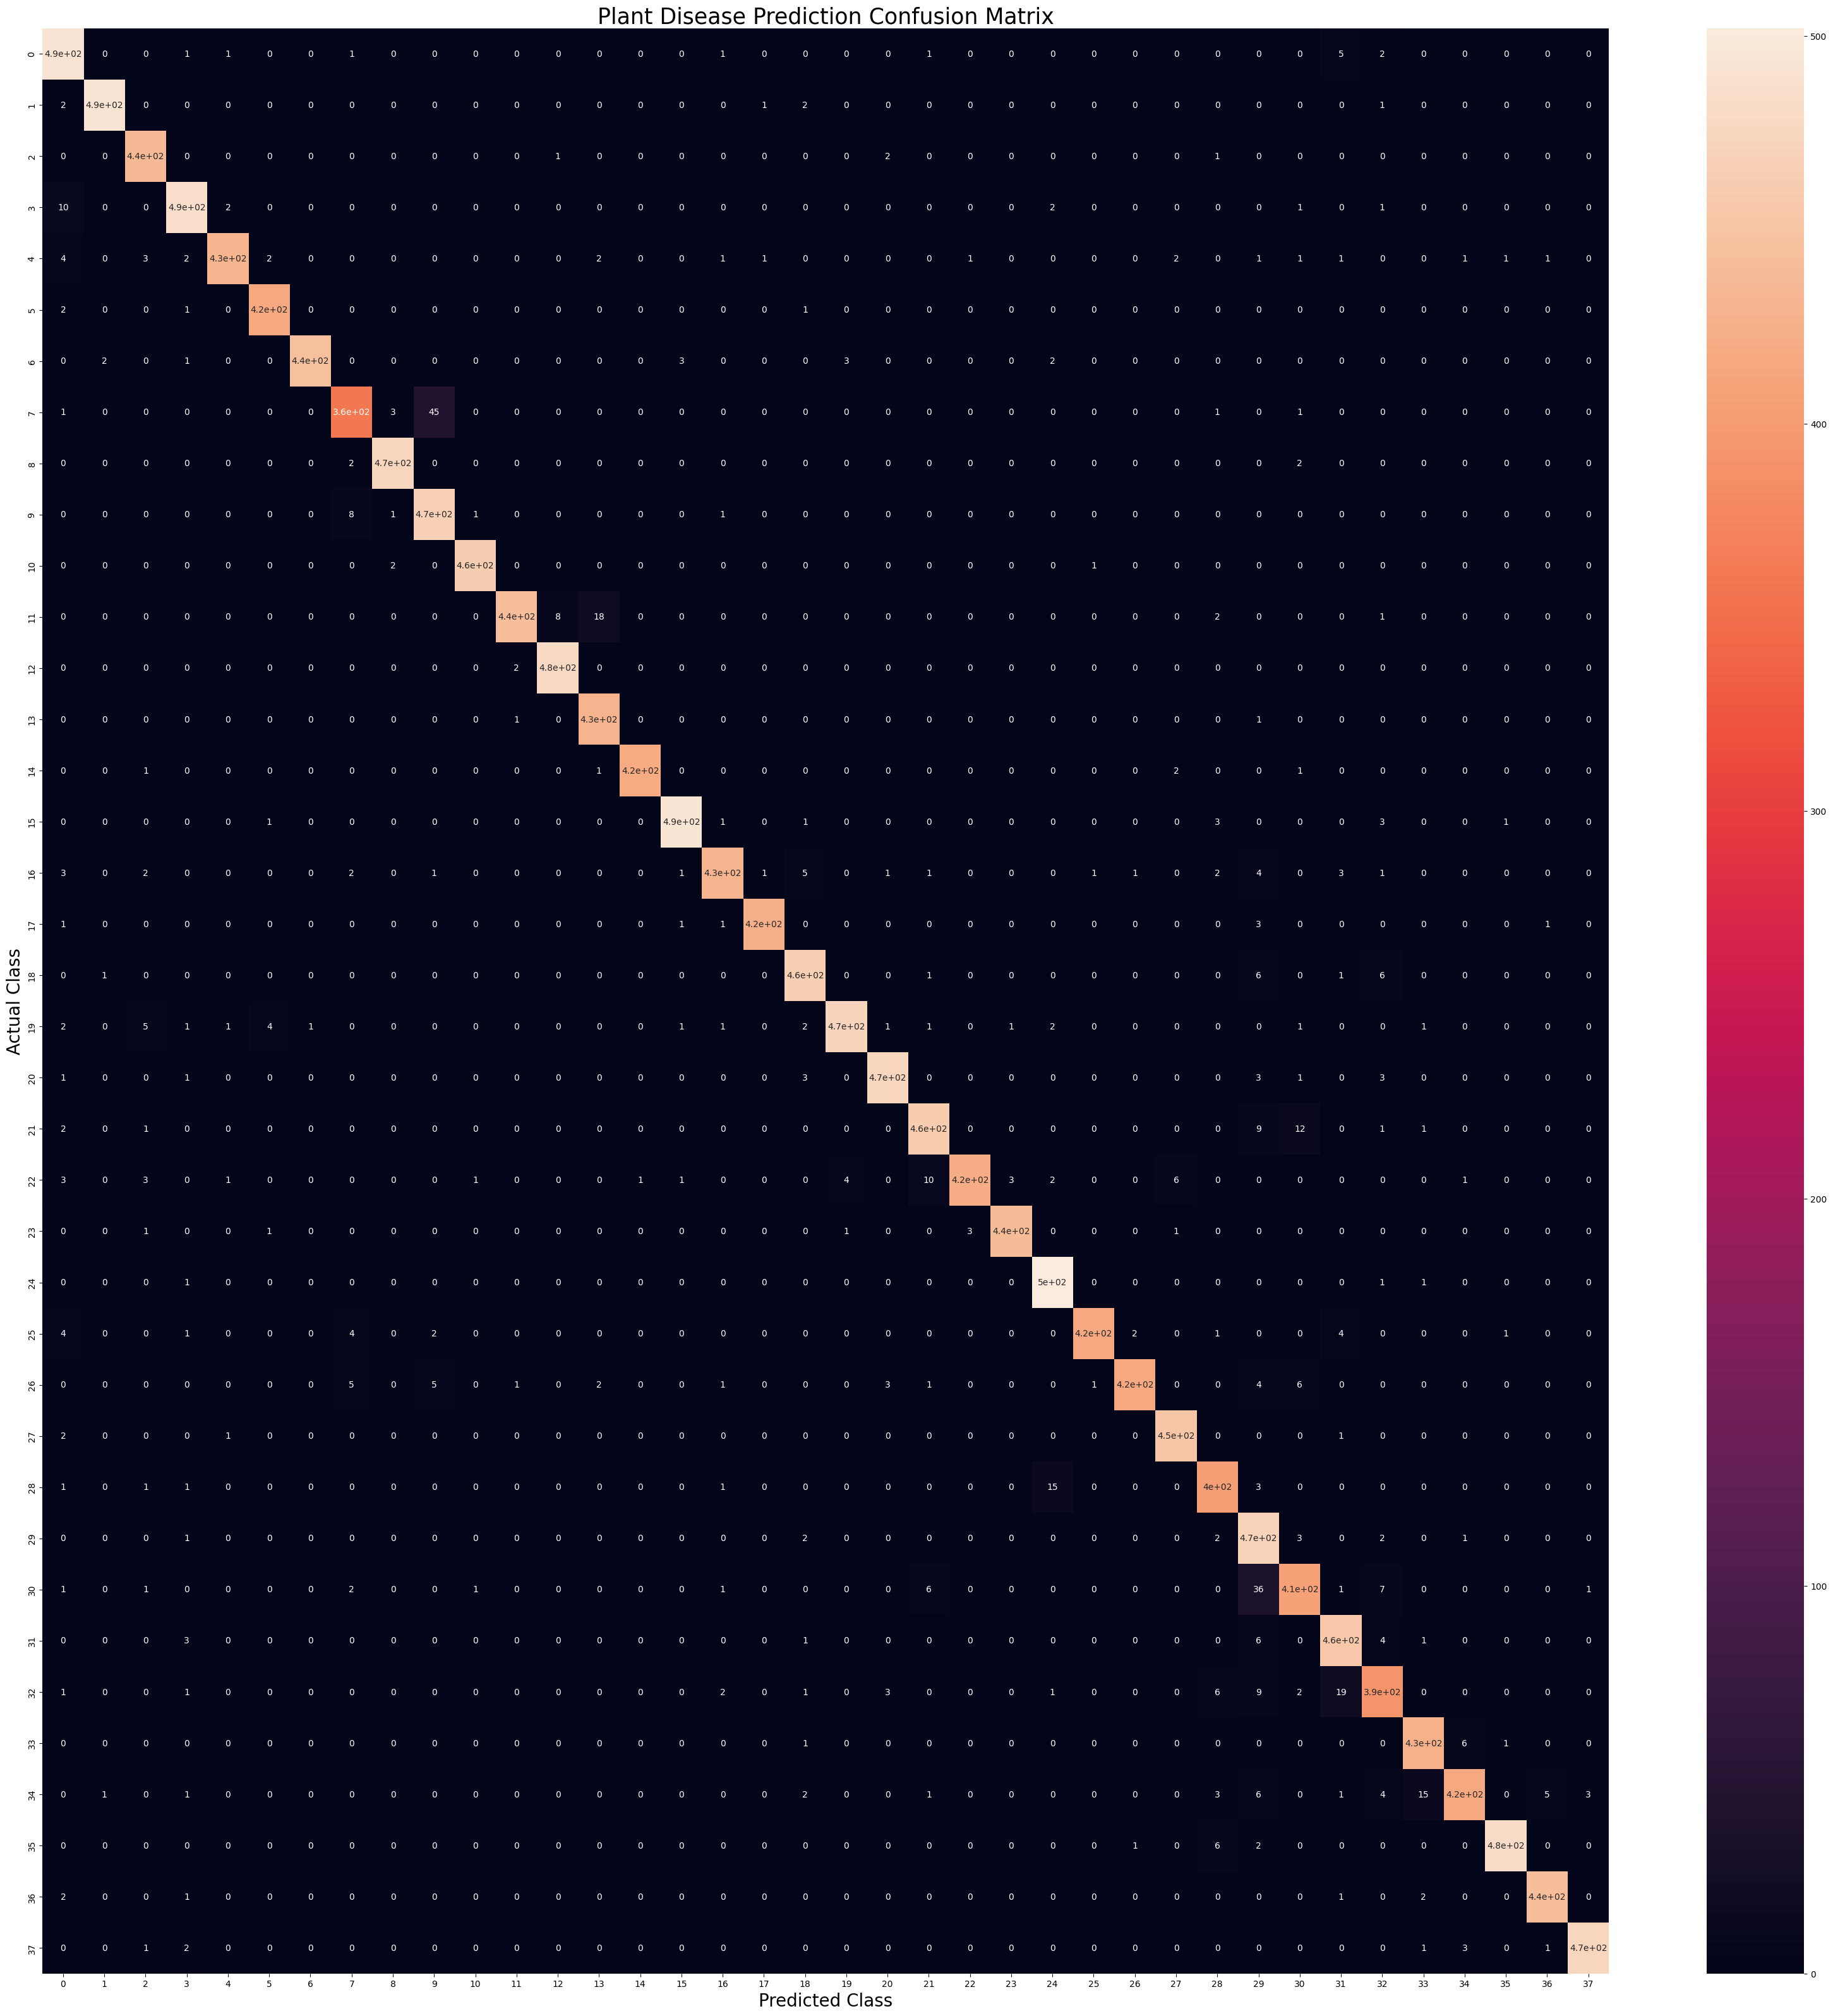

In [38]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()